# 06 – EC3D Zero-Shot Retrieval: Pose → Text

**Obiettivo**: Valutare le performance zero-shot del dual encoder pre-addestrato (su FLAG3D) nella retrieval Pose→Text su EC3D.

## Strategie di annotazione testuale:

1. **Template Generici** (`generic_templates.txt`): Frasi semplici e uniformi
   - Esempio: *"The subject is performing a squat with correct form."*

2. **Annotazioni FLAG3D-style** (`AxxxI00n.txt`): Descrizioni dettagliate multiple per classe
   - Esempio: *"Stand tall, bend your knees and lower into a squat keeping the back straight."*

## Metriche:
- Recall@1, Recall@5
- Mean Average Precision (MAP)
- Analisi per classe e visualizzazioni

In [1]:
import sys
from pathlib import Path
import pickle
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Aggiungi root al path
ROOT_DIR = Path("..").resolve()
sys.path.insert(0, str(ROOT_DIR))
print(f"ROOT_DIR: {ROOT_DIR}")

from pose_encoder.twostream_stgcn_plus import TwoStreamSTGCNPlusEncoder
from text_encoder.distilbert_adapter import DistilBERTTextEncoder

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Seed per riproducibilità
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

ROOT_DIR: /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/models
Using device: cuda


## 1. Configurazione e Path

In [2]:
# === PATH ===
DATA_DIR = ROOT_DIR.parent / "data" / "EC3D"
ANNOTATIONS_DIR = ROOT_DIR.parent / "data" / "annotations_ec3d"
LOGS_DIR = ROOT_DIR.parent / "logs" / "t1.0"
OUTPUT_DIR = ROOT_DIR.parent / "debug_outputs" / "ec3d_zero_shot"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Checkpoint migliore
with open(LOGS_DIR / "best_epoch.txt", "r") as f:
    BEST_EPOCH = int(f.read().strip())
print(f"📌 Best epoch: {BEST_EPOCH}")

# === MAPPING CLASSI EC3D ===
ID_TO_NAME = {
    0: "SQUAT - Correct",
    1: "SQUAT - Feet too wide",
    2: "SQUAT - Knees inward",
    3: "SQUAT - Not deep enough",
    4: "SQUAT - Torso leaning forward",
    5: "SQUAT - Unknown error",
    6: "LUNGES - Correct",
    7: "LUNGES - Not deep enough",
    8: "LUNGES - Knees passing toes",
    9: "PLANK - Correct",
    10: "PLANK - Banana back",
    11: "PLANK - Rolled back"
}

SHORT_NAMES = {
    0: "SQ-OK", 1: "SQ-Wide", 2: "SQ-Knee", 3: "SQ-Shallow",
    4: "SQ-Lean", 5: "SQ-Unk", 6: "LU-OK", 7: "LU-Shallow",
    8: "LU-Knee", 9: "PL-OK", 10: "PL-Banana", 11: "PL-Roll"
}

print(f"\n📊 {len(ID_TO_NAME)} classi EC3D")

📌 Best epoch: 28

📊 12 classi EC3D


## 2. Caricamento Annotazioni Testuali

In [3]:
def load_generic_templates(path):
    """
    Carica i template generici (1 per classe).
    
    Returns:
        dict: {class_id: template_string}
    """
    templates = {}
    with open(path, 'r') as f:
        for i, line in enumerate(f):
            line = line.strip()
            if line:  # Ignora righe vuote
                templates[i] = line
    return templates

def load_flag3d_style_annotations(annotations_dir, num_classes=12, annotations_per_class=6):
    """
    Carica le annotazioni FLAG3D-style (multiple per classe).
    
    File naming: AxxxI00n.txt dove xxx=class_id, n=annotation_index
    
    Returns:
        dict: {class_id: [list of annotation strings]}
    """
    annotations = {i: [] for i in range(num_classes)}
    
    for class_id in range(num_classes):
        for ann_idx in range(1, annotations_per_class + 1):
            # Formato: A000I001.txt, A001I002.txt, etc.
            filename = f"A{class_id:03d}I{ann_idx:03d}.txt"
            filepath = annotations_dir / filename
            
            if filepath.exists():
                with open(filepath, 'r') as f:
                    text = f.read().strip()
                    if text:
                        annotations[class_id].append(text)
    
    return annotations

# Carica entrambi i tipi di annotazioni
generic_templates = load_generic_templates(ANNOTATIONS_DIR / "generic_templates.txt")
flag3d_annotations = load_flag3d_style_annotations(ANNOTATIONS_DIR)

print("\n📝 TEMPLATE GENERICI:")
for cid, text in generic_templates.items():
    print(f"  [{cid:2d}] {text[:70]}..." if len(text) > 70 else f"  [{cid:2d}] {text}")

print(f"\n📝 ANNOTAZIONI FLAG3D-STYLE:")
for cid, texts in flag3d_annotations.items():
    print(f"  [{cid:2d}] {len(texts)} annotazioni - Es: \"{texts[0][:50]}...\"" if texts else f"  [{cid:2d}] VUOTO")


📝 TEMPLATE GENERICI:
  [ 0] The subject is performing Squat (Correct)
  [ 1] The subject is performing Squat (Feet too wide)
  [ 2] The subject is performing Squat (Knees inward)
  [ 3] The subject is performing Squat (Not low enough)
  [ 4] The subject is performing Squat (Front bended)
  [ 5] The subject is performing Squat (Unknown error)
  [ 6] The subject is performing Lunges (Correct)
  [ 7] The subject is performing Lunges (Not low enough)
  [ 8] The subject is performing Lunges (Knees pass toes)
  [ 9] The subject is performing Plank (Correct)
  [10] The subject is performing Plank (Banana back)
  [11] The subject is performing Plank (Rolled back)

📝 ANNOTAZIONI FLAG3D-STYLE:
  [ 0] 6 annotazioni - Es: "Squat (Correct)..."
  [ 1] 6 annotazioni - Es: "Squat (Feet too wide)..."
  [ 2] 6 annotazioni - Es: "Squat (Knees inward)..."
  [ 3] 6 annotazioni - Es: "Squat (Not low enough)..."
  [ 4] 6 annotazioni - Es: "Squat (Front bended)..."
  [ 5] 6 annotazioni - Es: "Squat (Unknown 

## 3. Caricamento Dataset EC3D

In [4]:
# Carica sequenze
with open(DATA_DIR / "ec3d_sequences.pkl", "rb") as f:
    ec3d_data = pickle.load(f)

# Carica split cross-subject
with open(DATA_DIR / "split_cross_subject.json", "r") as f:
    split = json.load(f)

sequences = ec3d_data["sequences"]  # lista di np.array (T, 3, 25)
labels = np.array(ec3d_data["labels"])  # np.array (N_seq,)

test_indices = np.array(split["test_indices"])

print(f"\n📥 Dataset EC3D caricato:")
print(f"   Totale sequenze: {len(sequences)}")
print(f"   Test set: {len(test_indices)} sequenze")
print(f"   Numero classi: {len(np.unique(labels))}")
print(f"   Esempio shape sequenza: {sequences[0].shape}")

# Distribuzione classi nel test set
test_labels = labels[test_indices]
print(f"\n📊 Distribuzione classi (test set):")
for cid in range(12):
    count = np.sum(test_labels == cid)
    print(f"   [{cid:2d}] {SHORT_NAMES[cid]:12s}: {count} samples")


📥 Dataset EC3D caricato:
   Totale sequenze: 371
   Test set: 88 sequenze
   Numero classi: 12
   Esempio shape sequenza: (64, 3, 25)

📊 Distribuzione classi (test set):
   [ 0] SQ-OK       : 10 samples
   [ 1] SQ-Wide     : 5 samples
   [ 2] SQ-Knee     : 5 samples
   [ 3] SQ-Shallow  : 4 samples
   [ 4] SQ-Lean     : 7 samples
   [ 5] SQ-Unk      : 0 samples
   [ 6] LU-OK       : 12 samples
   [ 7] LU-Shallow  : 10 samples
   [ 8] LU-Knee     : 10 samples
   [ 9] PL-OK       : 7 samples
   [10] PL-Banana   : 9 samples
   [11] PL-Roll     : 9 samples


## 4. Caricamento Dual Encoder Pre-addestrato

In [5]:
# === CARICA POSE ENCODER ===
print(f"\n📦 Caricamento Pose Encoder (epoch {BEST_EPOCH})...")
pose_encoder = TwoStreamSTGCNPlusEncoder(
    input_dim=3,
    hidden_channels=[64, 128, 256, 256],
    output_dim=128,
    num_nodes=25,
    dropout=0.1,
    fusion_dropout=0.3
)

pose_ckpt = torch.load(LOGS_DIR / f"pose_encoder_epoch{BEST_EPOCH}.pt", map_location=device)
pose_encoder.load_state_dict(pose_ckpt)
pose_encoder.to(device)
pose_encoder.eval()
print(f"   ✅ Pose encoder caricato")

# === CARICA TEXT ENCODER ===
print(f"\n📦 Caricamento Text Encoder (epoch {BEST_EPOCH})...")
text_encoder = DistilBERTTextEncoder(
    pretrained_model='distilbert-base-uncased',
    output_dim=128,
    freeze_bert=True,
    use_adapter=True,
    adapter_bottleneck=256
)

text_ckpt = torch.load(LOGS_DIR / f"text_encoder_epoch{BEST_EPOCH}.pt", map_location=device)
text_encoder.load_state_dict(text_ckpt)
text_encoder.to(device)
text_encoder.eval()
print(f"   ✅ Text encoder caricato")


📦 Caricamento Pose Encoder (epoch 28)...
   ✅ Pose encoder caricato

📦 Caricamento Text Encoder (epoch 28)...
🧊 DistilBERT congelato (100 parametri)
🔧 Adapter attivo (bottleneck=256)
📊 Text Encoder: 494,208 trainabili / 66,857,088 totali
   ✅ Text encoder caricato


## 5. Funzioni di Encoding

In [6]:
def encode_texts(text_encoder, texts, device, batch_size=32):
    """
    Codifica una lista di testi in embedding.
    
    Returns:
        np.ndarray: (N, D) array di embedding normalizzati L2
    """
    embeddings = []
    
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        
        # Tokenizza
        encoded = text_encoder.tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        )
        
        input_ids = encoded['input_ids'].to(device)
        attention_mask = encoded['attention_mask'].to(device)
        
        with torch.no_grad():
            emb = text_encoder(input_ids, attention_mask)
            emb = F.normalize(emb, p=2, dim=1)  # L2 normalization
            embeddings.append(emb.cpu().numpy())
    
    return np.vstack(embeddings)


def encode_poses(pose_encoder, sequences, indices, device, max_len=100):
    """
    Codifica le sequenze di pose in embedding.
    
    Args:
        sequences: lista di array (T, 3, 25)
        indices: indici delle sequenze da codificare
        max_len: lunghezza massima per padding/truncation
    
    Returns:
        np.ndarray: (N, D) array di embedding normalizzati L2
    """
    embeddings = []
    
    for idx in tqdm(indices, desc="Encoding poses"):
        seq = sequences[idx]  # (T, 3, 25)
        
        # Trasposizione: (T, 3, 25) -> (T, 25, 3)
        seq = np.transpose(seq, (0, 2, 1))
        T, V, C = seq.shape
        
        # Padding/Truncation
        if T < max_len:
            pad = np.zeros((max_len - T, V, C), dtype=np.float32)
            seq = np.concatenate([seq, pad], axis=0)
        elif T > max_len:
            # Uniform sampling
            sample_indices = np.linspace(0, T - 1, max_len).astype(int)
            seq = seq[sample_indices]
        
        # Converti in tensor
        seq_tensor = torch.from_numpy(seq.astype(np.float32)).unsqueeze(0).to(device)
        
        with torch.no_grad():
            emb = pose_encoder(seq_tensor)  # (1, D)
            embeddings.append(emb.cpu().numpy())
    
    return np.vstack(embeddings)

## 6. Metriche di Retrieval

In [7]:
def compute_retrieval_metrics(similarities, ground_truth_labels, num_classes=12):
    """
    Calcola metriche di retrieval Pose → Text.
    
    Args:
        similarities: (N_samples, N_classes) matrice di similarità
        ground_truth_labels: (N_samples,) label veri
        num_classes: numero di classi
    
    Returns:
        dict con metriche aggregate e per-sample
    """
    N = len(ground_truth_labels)
    
    # Ranking per ogni sample (indici ordinati per similarità decrescente)
    rankings = np.argsort(-similarities, axis=1)
    
    # Predictions top-1
    top1_preds = rankings[:, 0]
    
    # Recall@1
    recall_at_1 = np.mean(top1_preds == ground_truth_labels)
    
    # Recall@5
    recall_at_5 = np.mean([gt in rankings[i, :5] for i, gt in enumerate(ground_truth_labels)])
    
    # Mean Reciprocal Rank (MRR)
    reciprocal_ranks = []
    for i, gt in enumerate(ground_truth_labels):
        rank = np.where(rankings[i] == gt)[0][0] + 1  # 1-indexed
        reciprocal_ranks.append(1.0 / rank)
    mrr = np.mean(reciprocal_ranks)
    
    # Mean Average Precision (MAP) - per retrieval single-label
    # Per ogni query, AP = 1/rank se corretto
    map_score = mrr  # Equivalente per single-label
    
    # Per-class accuracy
    per_class_acc = {}
    for cid in range(num_classes):
        mask = ground_truth_labels == cid
        if np.sum(mask) > 0:
            per_class_acc[cid] = np.mean(top1_preds[mask] == cid)
        else:
            per_class_acc[cid] = 0.0
    
    return {
        'recall@1': recall_at_1,
        'recall@5': recall_at_5,
        'mrr': mrr,
        'map': map_score,
        'per_class_acc': per_class_acc,
        'predictions': top1_preds,
        'rankings': rankings,
        'similarities': similarities
    }

## 7. Encoding delle Pose (Test Set)

In [8]:
# Codifica tutte le pose del test set
print("\n🏃 Encoding pose del test set...")
pose_embeddings = encode_poses(pose_encoder, sequences, test_indices, device, max_len=100)
print(f"   Shape: {pose_embeddings.shape}")


🏃 Encoding pose del test set...


Encoding poses:   0%|          | 0/88 [00:00<?, ?it/s]

   Shape: (88, 128)


---

# Strategia 1: Template Generici

Ogni classe è rappresentata da **un singolo template** (dal file `generic_templates.txt`).

In [11]:
# Prepara testi per ogni classe
generic_texts = [generic_templates[i] for i in range(12)]

print("\n💬 Encoding template generici...")
generic_text_embeddings = encode_texts(text_encoder, generic_texts, device)
print(f"   Shape: {generic_text_embeddings.shape}")

# Calcola similarità
sims_generic = cosine_similarity(pose_embeddings, generic_text_embeddings)

# Metriche
metrics_generic = compute_retrieval_metrics(sims_generic, test_labels)

print("\n" + "="*60)
print("🎯 STRATEGIA 1: TEMPLATE GENERICI")
print("="*60)
print(f"   Recall@1:  {metrics_generic['recall@1']:.4f} ({metrics_generic['recall@1']*100:.1f}%)")
print(f"   Recall@5:  {metrics_generic['recall@5']:.4f} ({metrics_generic['recall@5']*100:.1f}%)")
print(f"   MRR:       {metrics_generic['mrr']:.4f}")
print(f"   MAP:       {metrics_generic['map']:.4f}")


💬 Encoding template generici...
   Shape: (12, 128)

🎯 STRATEGIA 1: TEMPLATE GENERICI
   Recall@1:  0.0795 (8.0%)
   Recall@5:  0.2727 (27.3%)
   MRR:       0.2186
   MAP:       0.2186


In [12]:
# Per-class accuracy
print("\n📊 Accuracy per classe (Template Generici):")
for cid, acc in metrics_generic['per_class_acc'].items():
    print(f"   [{cid:2d}] {SHORT_NAMES[cid]:12s}: {acc:.2%}")


📊 Accuracy per classe (Template Generici):
   [ 0] SQ-OK       : 0.00%
   [ 1] SQ-Wide     : 0.00%
   [ 2] SQ-Knee     : 0.00%
   [ 3] SQ-Shallow  : 0.00%
   [ 4] SQ-Lean     : 100.00%
   [ 5] SQ-Unk      : 0.00%
   [ 6] LU-OK       : 0.00%
   [ 7] LU-Shallow  : 0.00%
   [ 8] LU-Knee     : 0.00%
   [ 9] PL-OK       : 0.00%
   [10] PL-Banana   : 0.00%
   [11] PL-Roll     : 0.00%


---

# Strategia 2: Annotazioni FLAG3D-Style

Ogni classe è rappresentata da **multiple annotazioni dettagliate**.

Strategie di aggregazione:
- **Media embedding**: calcola l'embedding medio di tutte le annotazioni per classe
- **Max similarity**: per ogni pose, prendi la massima similarità tra tutte le annotazioni della classe

In [13]:
# Codifica tutte le annotazioni FLAG3D-style
print("\n💬 Encoding annotazioni FLAG3D-style...")

# Crea lista piatta di tutti i testi e mappa classe
all_flag3d_texts = []
text_to_class = []

for cid, texts in flag3d_annotations.items():
    for text in texts:
        all_flag3d_texts.append(text)
        text_to_class.append(cid)

text_to_class = np.array(text_to_class)

print(f"   Totale annotazioni: {len(all_flag3d_texts)}")

# Codifica tutti i testi
all_flag3d_embeddings = encode_texts(text_encoder, all_flag3d_texts, device)
print(f"   Shape embedding: {all_flag3d_embeddings.shape}")


💬 Encoding annotazioni FLAG3D-style...
   Totale annotazioni: 72
   Shape embedding: (72, 128)


### Strategia 2a: Media degli Embedding per Classe

In [14]:
# Calcola embedding medio per ogni classe
flag3d_mean_embeddings = np.zeros((12, all_flag3d_embeddings.shape[1]))

for cid in range(12):
    mask = text_to_class == cid
    if np.sum(mask) > 0:
        flag3d_mean_embeddings[cid] = all_flag3d_embeddings[mask].mean(axis=0)
        # Re-normalizza L2
        flag3d_mean_embeddings[cid] /= np.linalg.norm(flag3d_mean_embeddings[cid])

# Calcola similarità
sims_flag3d_mean = cosine_similarity(pose_embeddings, flag3d_mean_embeddings)

# Metriche
metrics_flag3d_mean = compute_retrieval_metrics(sims_flag3d_mean, test_labels)

print("\n" + "="*60)
print("🎯 STRATEGIA 2a: FLAG3D-STYLE (Media Embedding)")
print("="*60)
print(f"   Recall@1:  {metrics_flag3d_mean['recall@1']:.4f} ({metrics_flag3d_mean['recall@1']*100:.1f}%)")
print(f"   Recall@5:  {metrics_flag3d_mean['recall@5']:.4f} ({metrics_flag3d_mean['recall@5']*100:.1f}%)")
print(f"   MRR:       {metrics_flag3d_mean['mrr']:.4f}")
print(f"   MAP:       {metrics_flag3d_mean['map']:.4f}")


🎯 STRATEGIA 2a: FLAG3D-STYLE (Media Embedding)
   Recall@1:  0.0795 (8.0%)
   Recall@5:  0.6023 (60.2%)
   MRR:       0.2807
   MAP:       0.2807


### Strategia 2b: Max Similarity per Classe

In [15]:
# Calcola similarità con tutti i testi
sims_all = cosine_similarity(pose_embeddings, all_flag3d_embeddings)  # (N_samples, N_texts)

# Per ogni classe, prendi la max similarity
sims_flag3d_max = np.zeros((len(test_labels), 12))

for cid in range(12):
    mask = text_to_class == cid
    if np.sum(mask) > 0:
        sims_flag3d_max[:, cid] = sims_all[:, mask].max(axis=1)

# Metriche
metrics_flag3d_max = compute_retrieval_metrics(sims_flag3d_max, test_labels)

print("\n" + "="*60)
print("🎯 STRATEGIA 2b: FLAG3D-STYLE (Max Similarity)")
print("="*60)
print(f"   Recall@1:  {metrics_flag3d_max['recall@1']:.4f} ({metrics_flag3d_max['recall@1']*100:.1f}%)")
print(f"   Recall@5:  {metrics_flag3d_max['recall@5']:.4f} ({metrics_flag3d_max['recall@5']*100:.1f}%)")
print(f"   MRR:       {metrics_flag3d_max['mrr']:.4f}")
print(f"   MAP:       {metrics_flag3d_max['map']:.4f}")


🎯 STRATEGIA 2b: FLAG3D-STYLE (Max Similarity)
   Recall@1:  0.0795 (8.0%)
   Recall@5:  0.3750 (37.5%)
   MRR:       0.2388
   MAP:       0.2388


---

# 8. Confronto delle Strategie

In [16]:
# Tabella riassuntiva
comparison_df = pd.DataFrame({
    'Strategia': ['Template Generici', 'FLAG3D-Style (Mean)', 'FLAG3D-Style (Max)'],
    'Recall@1': [
        metrics_generic['recall@1'],
        metrics_flag3d_mean['recall@1'],
        metrics_flag3d_max['recall@1']
    ],
    'Recall@5': [
        metrics_generic['recall@5'],
        metrics_flag3d_mean['recall@5'],
        metrics_flag3d_max['recall@5']
    ],
    'MRR': [
        metrics_generic['mrr'],
        metrics_flag3d_mean['mrr'],
        metrics_flag3d_max['mrr']
    ],
    'MAP': [
        metrics_generic['map'],
        metrics_flag3d_mean['map'],
        metrics_flag3d_max['map']
    ]
})

print("\n" + "="*70)
print("📊 CONFRONTO STRATEGIE ZERO-SHOT RETRIEVAL (Pose → Text)")
print("="*70)
print(comparison_df.to_string(index=False))

# Salva tabella
comparison_df.to_csv(OUTPUT_DIR / "retrieval_comparison.csv", index=False)
print(f"\n💾 Salvato in {OUTPUT_DIR / 'retrieval_comparison.csv'}")


📊 CONFRONTO STRATEGIE ZERO-SHOT RETRIEVAL (Pose → Text)
          Strategia  Recall@1  Recall@5      MRR      MAP
  Template Generici  0.079545  0.272727 0.218611 0.218611
FLAG3D-Style (Mean)  0.079545  0.602273 0.280698 0.280698
 FLAG3D-Style (Max)  0.079545  0.375000 0.238787 0.238787

💾 Salvato in /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/debug_outputs/ec3d_zero_shot/retrieval_comparison.csv


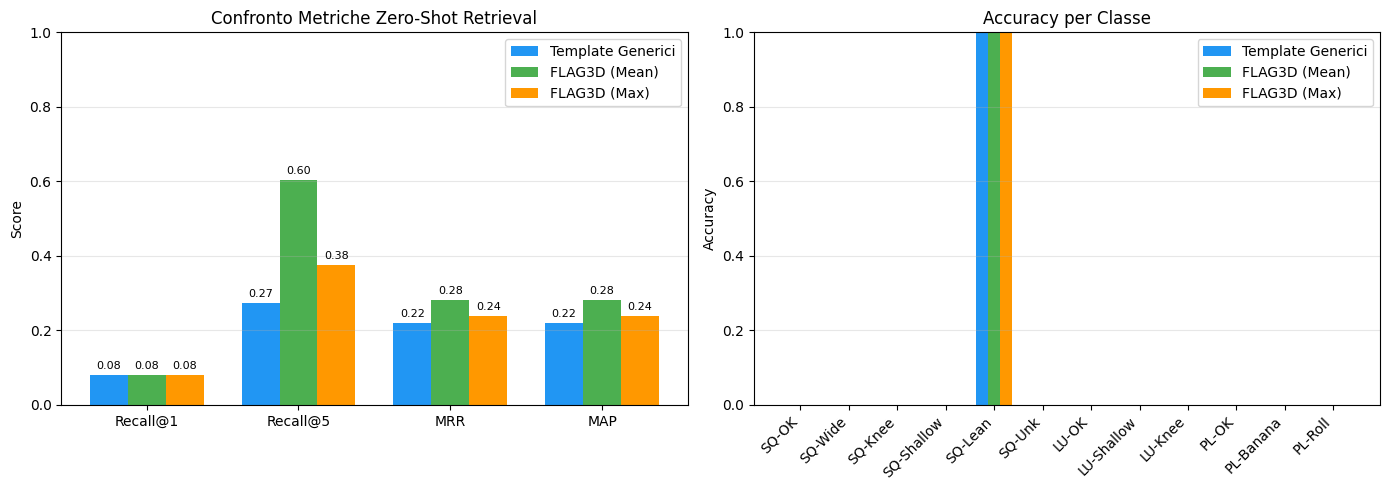

💾 Salvato in /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/debug_outputs/ec3d_zero_shot/retrieval_comparison_plot.png


In [17]:
# Visualizzazione confronto
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot metriche
metrics_names = ['Recall@1', 'Recall@5', 'MRR', 'MAP']
x = np.arange(len(metrics_names))
width = 0.25

ax1 = axes[0]
bars1 = ax1.bar(x - width, comparison_df.iloc[0, 1:].values, width, label='Template Generici', color='#2196F3')
bars2 = ax1.bar(x, comparison_df.iloc[1, 1:].values, width, label='FLAG3D (Mean)', color='#4CAF50')
bars3 = ax1.bar(x + width, comparison_df.iloc[2, 1:].values, width, label='FLAG3D (Max)', color='#FF9800')

ax1.set_ylabel('Score')
ax1.set_title('Confronto Metriche Zero-Shot Retrieval')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_names)
ax1.legend(loc='upper right')
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

# Aggiungi valori sopra le barre
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

# Per-class accuracy comparison
ax2 = axes[1]
class_names = [SHORT_NAMES[i] for i in range(12)]
x_classes = np.arange(12)

acc_generic = [metrics_generic['per_class_acc'][i] for i in range(12)]
acc_flag3d_mean = [metrics_flag3d_mean['per_class_acc'][i] for i in range(12)]
acc_flag3d_max = [metrics_flag3d_max['per_class_acc'][i] for i in range(12)]

ax2.bar(x_classes - width, acc_generic, width, label='Template Generici', color='#2196F3')
ax2.bar(x_classes, acc_flag3d_mean, width, label='FLAG3D (Mean)', color='#4CAF50')
ax2.bar(x_classes + width, acc_flag3d_max, width, label='FLAG3D (Max)', color='#FF9800')

ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy per Classe')
ax2.set_xticks(x_classes)
ax2.set_xticklabels(class_names, rotation=45, ha='right')
ax2.legend(loc='upper right')
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "retrieval_comparison_plot_afterresampling.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Salvato in {OUTPUT_DIR / 'retrieval_comparison_plot.png'}")

## 9. Confusion Matrix


🏆 Strategia migliore (Recall@1): Template Generici


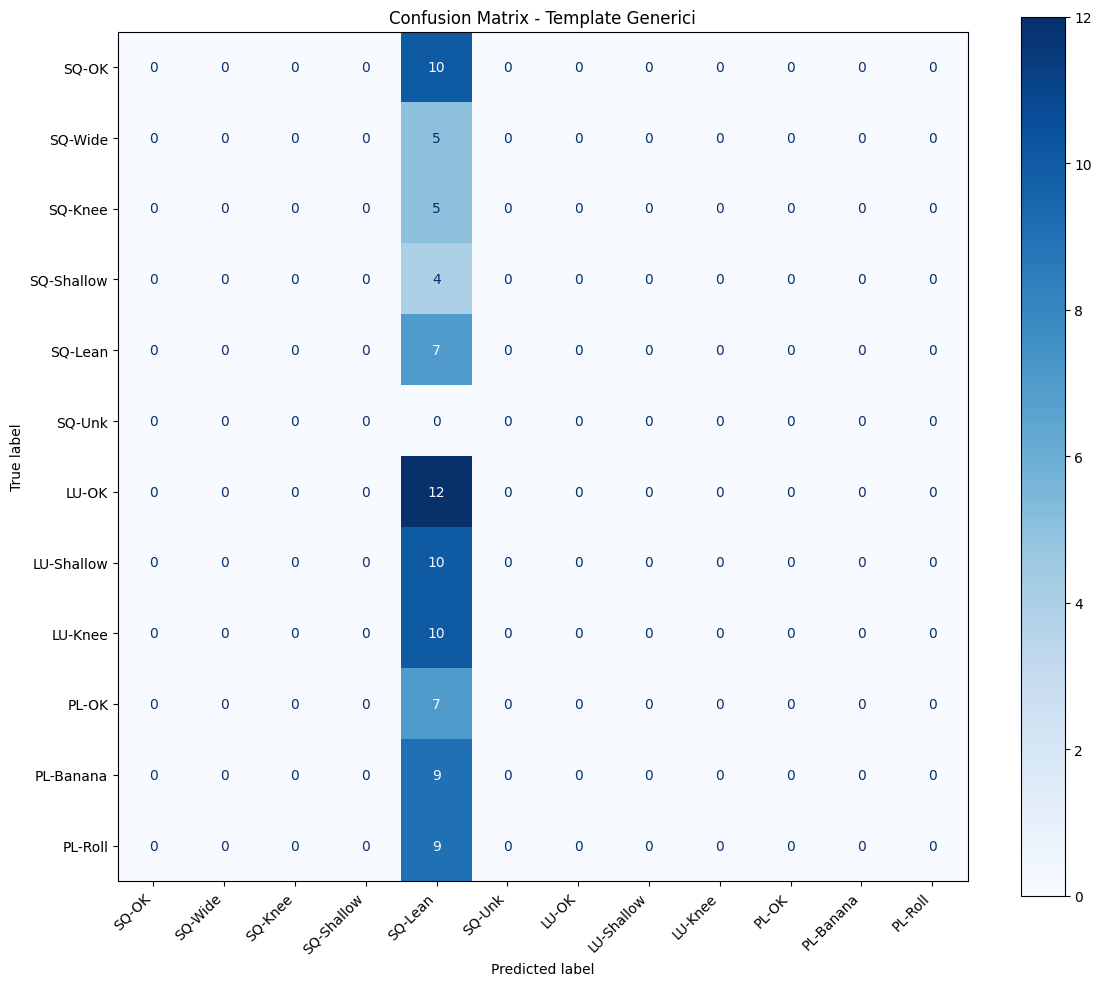

💾 Salvato in /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/debug_outputs/ec3d_zero_shot/confusion_matrix_best.png


In [18]:
# Scegli la strategia migliore per la confusion matrix
best_strategy = comparison_df.loc[comparison_df['Recall@1'].idxmax(), 'Strategia']
print(f"\n🏆 Strategia migliore (Recall@1): {best_strategy}")

# Usa le predizioni della strategia migliore
if 'Max' in best_strategy:
    best_preds = metrics_flag3d_max['predictions']
    best_sims = sims_flag3d_max
elif 'Mean' in best_strategy:
    best_preds = metrics_flag3d_mean['predictions']
    best_sims = sims_flag3d_mean
else:
    best_preds = metrics_generic['predictions']
    best_sims = sims_generic

# Confusion matrix
cm = confusion_matrix(test_labels, best_preds, labels=list(range(12)))

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(cm, display_labels=[SHORT_NAMES[i] for i in range(12)])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix - {best_strategy}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_best_afterresampling.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Salvato in {OUTPUT_DIR / 'confusion_matrix_best.png'}")

## 10. Analisi Distribuzione Similarità

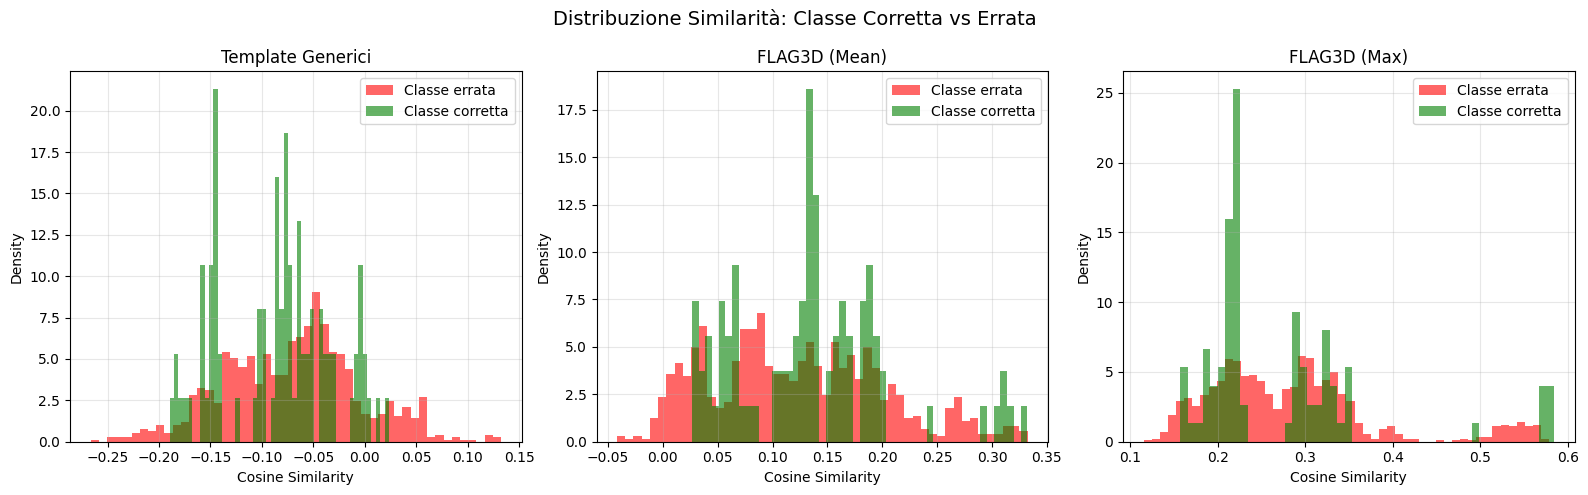

💾 Salvato in /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/debug_outputs/ec3d_zero_shot/similarity_distributions.png


In [19]:
# Analisi della distribuzione delle similarità
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

strategies = [
    ('Template Generici', sims_generic),
    ('FLAG3D (Mean)', sims_flag3d_mean),
    ('FLAG3D (Max)', sims_flag3d_max)
]

for ax, (name, sims) in zip(axes, strategies):
    # Similarità con la classe corretta vs altre
    correct_sims = []
    incorrect_sims = []
    
    for i, gt in enumerate(test_labels):
        correct_sims.append(sims[i, gt])
        for j in range(12):
            if j != gt:
                incorrect_sims.append(sims[i, j])
    
    ax.hist(incorrect_sims, bins=50, alpha=0.6, label='Classe errata', color='red', density=True)
    ax.hist(correct_sims, bins=50, alpha=0.6, label='Classe corretta', color='green', density=True)
    ax.set_xlabel('Cosine Similarity')
    ax.set_ylabel('Density')
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Distribuzione Similarità: Classe Corretta vs Errata', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "similarity_distributions_afterresampling.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Salvato in {OUTPUT_DIR / 'similarity_distributions.png'}")

## 11. Analisi Errori

In [20]:
# Analisi degli errori per la strategia migliore
errors_mask = best_preds != test_labels
error_indices = np.where(errors_mask)[0]

print(f"\n❌ Analisi Errori ({best_strategy}):")
print(f"   Totale errori: {len(error_indices)}/{len(test_labels)} ({len(error_indices)/len(test_labels)*100:.1f}%)")

# Coppie di confusione più frequenti
confusion_pairs = {}
for idx in error_indices:
    gt = test_labels[idx]
    pred = best_preds[idx]
    pair = (ID_TO_NAME[gt], ID_TO_NAME[pred])
    confusion_pairs[pair] = confusion_pairs.get(pair, 0) + 1

# Ordina per frequenza
sorted_pairs = sorted(confusion_pairs.items(), key=lambda x: x[1], reverse=True)

print("\n🔄 Coppie di confusione più frequenti:")
for (gt, pred), count in sorted_pairs[:10]:
    print(f"   {gt} → {pred}: {count}")


❌ Analisi Errori (Template Generici):
   Totale errori: 81/88 (92.0%)

🔄 Coppie di confusione più frequenti:
   LUNGES - Correct → SQUAT - Torso leaning forward: 12
   LUNGES - Not deep enough → SQUAT - Torso leaning forward: 10
   LUNGES - Knees passing toes → SQUAT - Torso leaning forward: 10
   SQUAT - Correct → SQUAT - Torso leaning forward: 10
   PLANK - Banana back → SQUAT - Torso leaning forward: 9
   PLANK - Rolled back → SQUAT - Torso leaning forward: 9
   PLANK - Correct → SQUAT - Torso leaning forward: 7
   SQUAT - Feet too wide → SQUAT - Torso leaning forward: 5
   SQUAT - Knees inward → SQUAT - Torso leaning forward: 5
   SQUAT - Not deep enough → SQUAT - Torso leaning forward: 4


In [21]:
# Heatmap delle confusioni per tipo di esercizio
exercise_types = {'SQUAT': [0,1,2,3,4,5], 'LUNGES': [6,7,8], 'PLANK': [9,10,11]}

print("\n📊 Confusione inter-esercizio vs intra-esercizio:")

inter_errors = 0  # Errori tra esercizi diversi
intra_errors = 0  # Errori dentro lo stesso esercizio

for idx in error_indices:
    gt = test_labels[idx]
    pred = best_preds[idx]
    
    gt_type = None
    pred_type = None
    for ex_type, classes in exercise_types.items():
        if gt in classes:
            gt_type = ex_type
        if pred in classes:
            pred_type = ex_type
    
    if gt_type == pred_type:
        intra_errors += 1
    else:
        inter_errors += 1

print(f"   Errori intra-esercizio (stesso tipo): {intra_errors} ({intra_errors/len(error_indices)*100:.1f}%)")
print(f"   Errori inter-esercizio (tipo diverso): {inter_errors} ({inter_errors/len(error_indices)*100:.1f}%)")


📊 Confusione inter-esercizio vs intra-esercizio:
   Errori intra-esercizio (stesso tipo): 24 (29.6%)
   Errori inter-esercizio (tipo diverso): 57 (70.4%)


## 12. Salvataggio Risultati

In [22]:
# Salva tutti i risultati
results = {
    'config': {
        'best_epoch': BEST_EPOCH,
        'test_samples': len(test_labels),
        'num_classes': 12
    },
    'template_generici': {
        'recall@1': float(metrics_generic['recall@1']),
        'recall@5': float(metrics_generic['recall@5']),
        'mrr': float(metrics_generic['mrr']),
        'map': float(metrics_generic['map']),
        'per_class_acc': {k: float(v) for k, v in metrics_generic['per_class_acc'].items()}
    },
    'flag3d_mean': {
        'recall@1': float(metrics_flag3d_mean['recall@1']),
        'recall@5': float(metrics_flag3d_mean['recall@5']),
        'mrr': float(metrics_flag3d_mean['mrr']),
        'map': float(metrics_flag3d_mean['map']),
        'per_class_acc': {k: float(v) for k, v in metrics_flag3d_mean['per_class_acc'].items()}
    },
    'flag3d_max': {
        'recall@1': float(metrics_flag3d_max['recall@1']),
        'recall@5': float(metrics_flag3d_max['recall@5']),
        'mrr': float(metrics_flag3d_max['mrr']),
        'map': float(metrics_flag3d_max['map']),
        'per_class_acc': {k: float(v) for k, v in metrics_flag3d_max['per_class_acc'].items()}
    },
    'best_strategy': best_strategy
}

with open(OUTPUT_DIR / "zero_shot_results.json", 'w') as f:
    json.dump(results, f, indent=2)

# Salva predizioni dettagliate
detailed_df = pd.DataFrame({
    'test_index': test_indices,
    'ground_truth': test_labels,
    'ground_truth_name': [ID_TO_NAME[l] for l in test_labels],
    'pred_generic': metrics_generic['predictions'],
    'pred_flag3d_mean': metrics_flag3d_mean['predictions'],
    'pred_flag3d_max': metrics_flag3d_max['predictions'],
    'correct_generic': metrics_generic['predictions'] == test_labels,
    'correct_flag3d_mean': metrics_flag3d_mean['predictions'] == test_labels,
    'correct_flag3d_max': metrics_flag3d_max['predictions'] == test_labels
})
detailed_df.to_csv(OUTPUT_DIR / "detailed_predictions_afterresampling.csv", index=False)

print(f"\n✅ Risultati salvati in {OUTPUT_DIR}:")
print("   - zero_shot_results.json")
print("   - retrieval_comparison.csv")
print("   - detailed_predictions.csv")
print("   - retrieval_comparison_plot.png")
print("   - confusion_matrix_best.png")
print("   - similarity_distributions.png")


✅ Risultati salvati in /home/giov/Scrivania/Tesi/pose-text-feedback-thesis/debug_outputs/ec3d_zero_shot:
   - zero_shot_results.json
   - retrieval_comparison.csv
   - detailed_predictions.csv
   - retrieval_comparison_plot.png
   - confusion_matrix_best.png
   - similarity_distributions.png


---

## 📋 Summary

Questo notebook valuta il dual encoder pre-addestrato su FLAG3D in uno scenario **zero-shot** su EC3D.

### Strategie testate:
1. **Template Generici**: un singolo template per classe
2. **FLAG3D-Style (Mean)**: media degli embedding di annotazioni multiple
3. **FLAG3D-Style (Max)**: massima similarità tra annotazioni multiple

### Key Findings:
- Confronta quale tipo di descrizione testuale funziona meglio per il transfer zero-shot
- Analisi degli errori per capire le limitazioni del modello
- Insight sulla separabilità delle classi nello spazio embedding condiviso